  All libraries loaded successfully.
    pandas 2.3.3 | numpy 2.3.5

  Dataset loaded  →  10,000 rows × 14 columns



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


         DATA QUALITY REPORT


,dtype,non_null,null,null_%,unique,sample_value
RowNumber,int64,10000,0,0.0,10000,1
CustomerId,int64,10000,0,0.0,10000,15634602
Surname,object,10000,0,0.0,2932,Hargrave
CreditScore,int64,10000,0,0.0,460,619
Geography,object,10000,0,0.0,3,France
Gender,object,10000,0,0.0,2,Female
Age,int64,10000,0,0.0,70,42
Tenure,int64,10000,0,0.0,11,2
Balance,float64,10000,0,0.0,6382,0.0
NumOfProducts,int64,10000,0,0.0,4,1


Duplicate rows: 0

  Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0



 Columns Retained After Cleaning


Feature No,Column Name
1,CreditScore
2,Geography
3,Gender
4,Age
5,Tenure
6,Balance
7,NumOfProducts
8,HasCrCard
9,IsActiveMember
10,EstimatedSalary



Working Dataset Shape: 10,000 Rows × 11 Columns


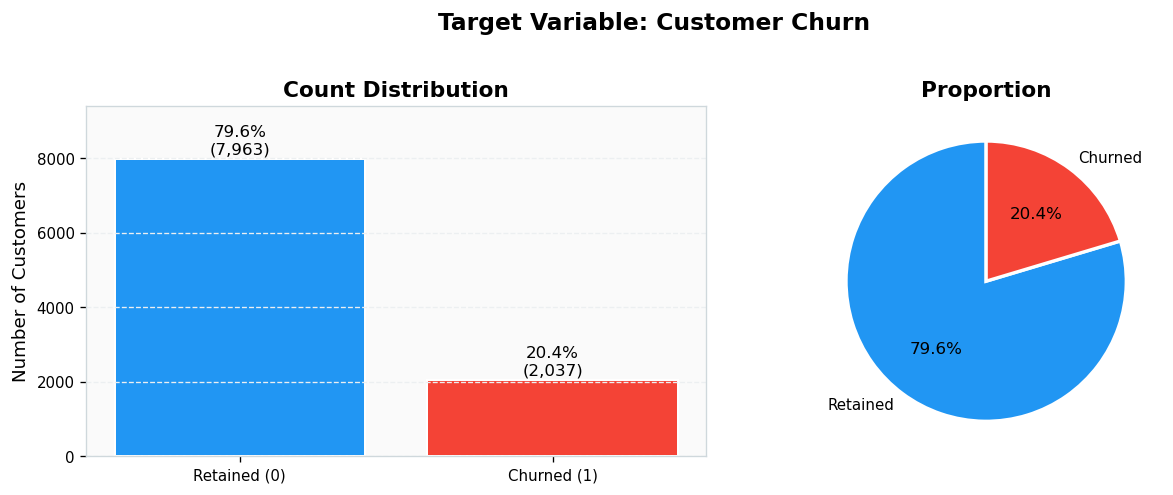

  Class Imbalance: 20.4% churn rate — models will need AUC / F1 evaluation.


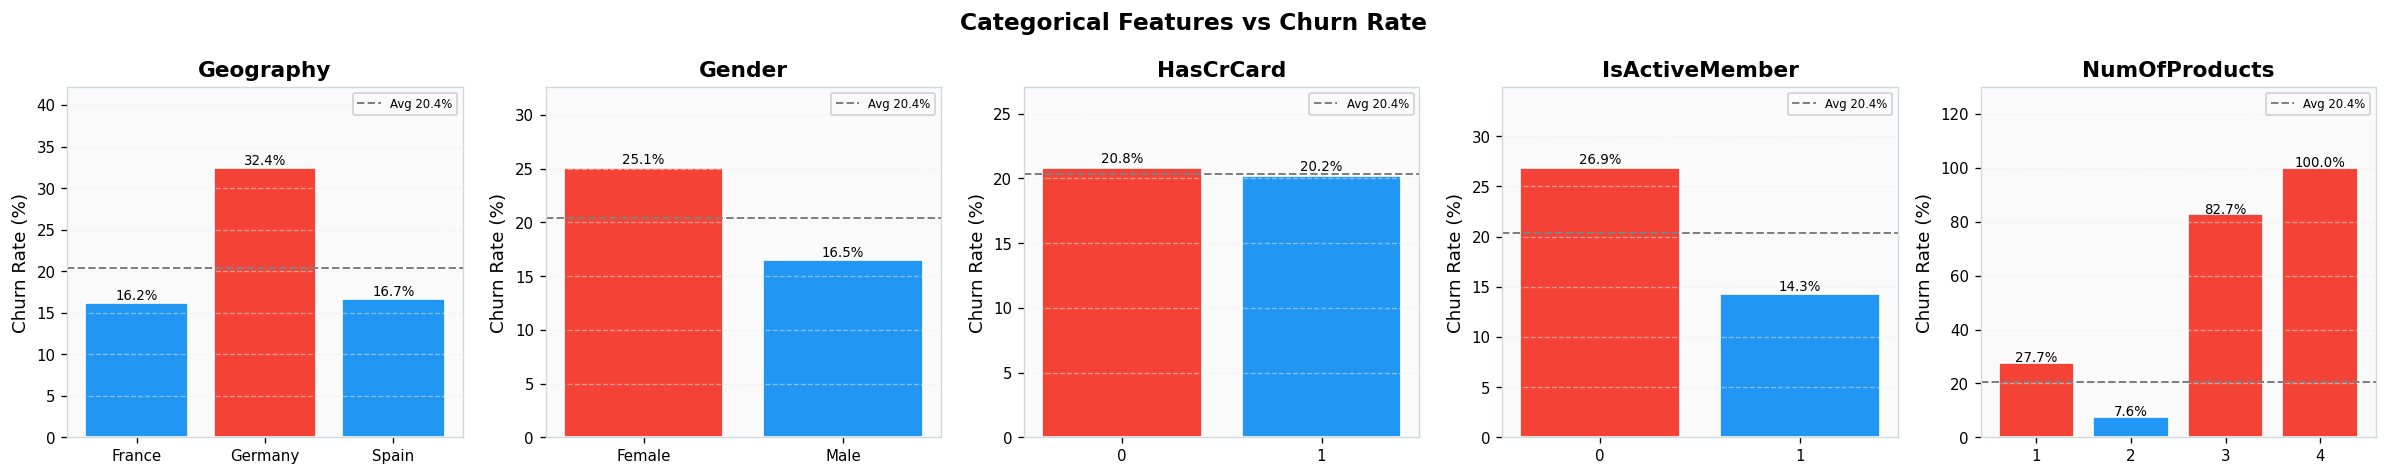

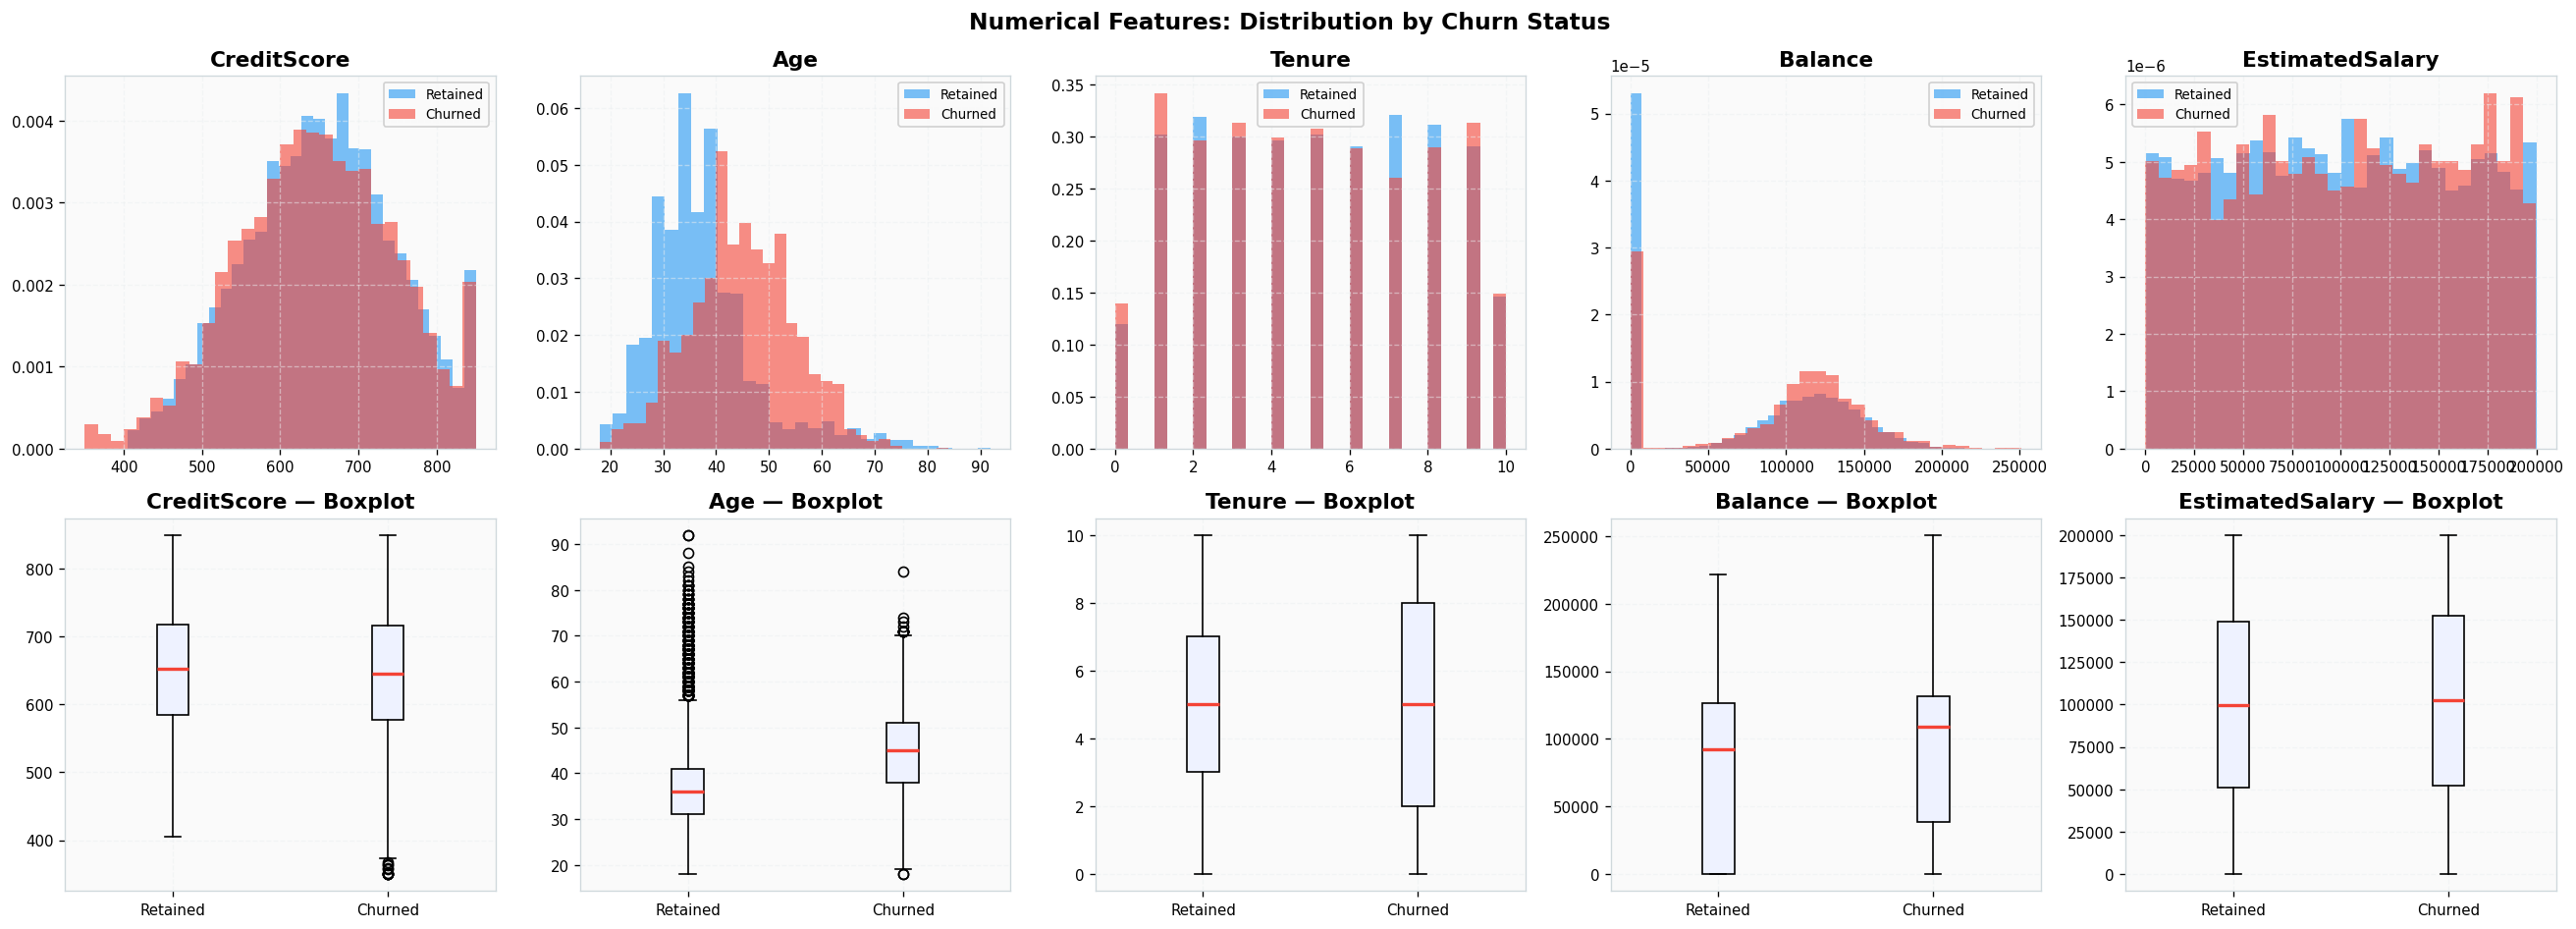

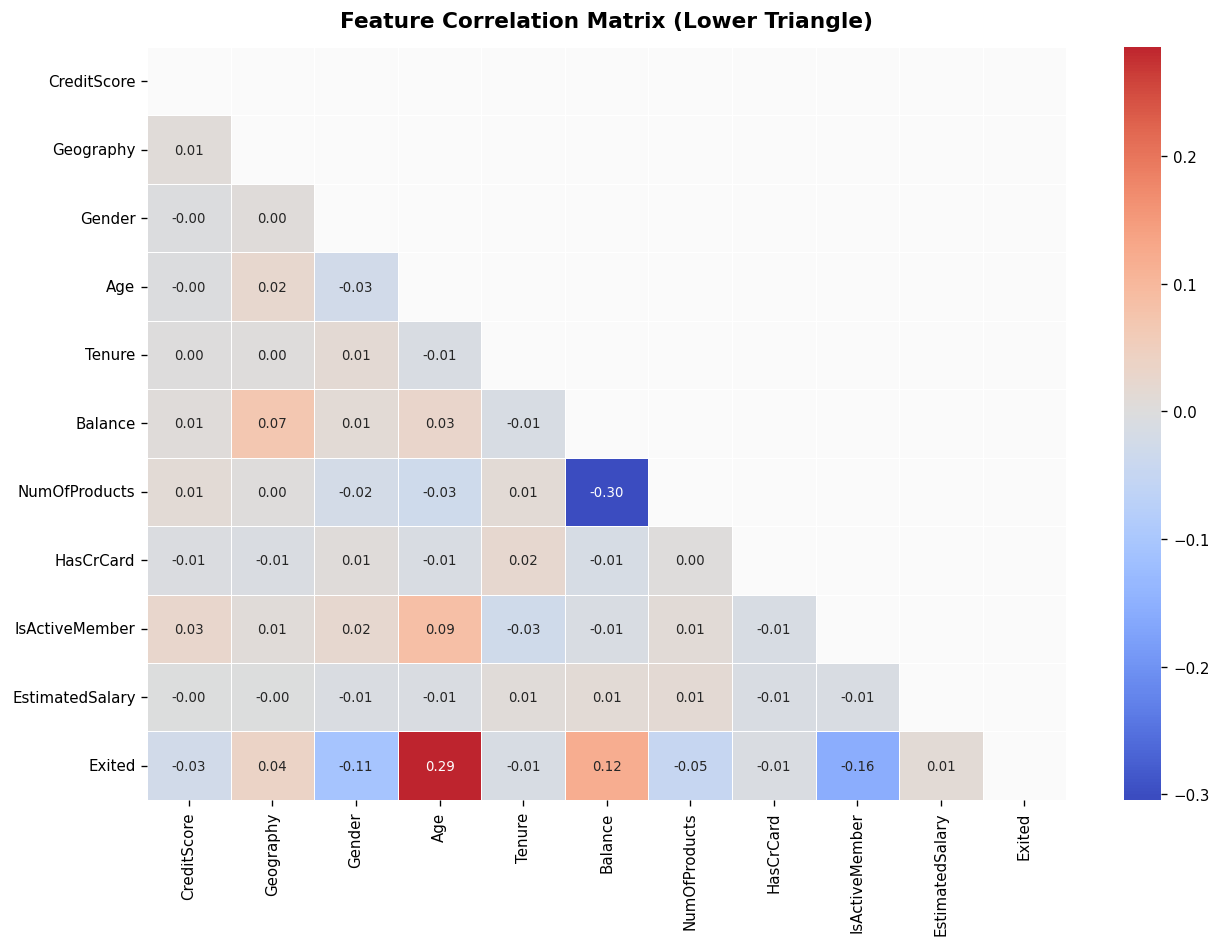


📊  Correlation with 'Exited' (absolute, descending):
Age                0.285323
IsActiveMember     0.156128
Balance            0.118533
Gender             0.106512
NumOfProducts      0.047820
Geography          0.035943
CreditScore        0.027094
Tenure             0.014001
EstimatedSalary    0.012097
HasCrCard          0.007138
  Engineered features added:


,Balance_Salary_Ratio,Products_per_Tenure,AgeGroup
0,0.0000,0.3333,41-50
1,0.7447,0.5000,41-50
2,1.4014,0.3333,41-50
3,0.0000,1.0000,31-40
4,1.5870,0.3333,41-50



📋 Final Feature Set


Feature No,Feature Name
1,CreditScore
2,Gender
3,Age
4,Tenure
5,Balance
6,NumOfProducts
7,HasCrCard
8,IsActiveMember
9,EstimatedSalary
10,Balance_Salary_Ratio



Total Features: 17

 Train-Test Split Summary


,Dataset,Rows,Features,Churn Rate
0,Training Set,8000,17,20.38
1,Testing Set,2000,17,20.35


In [ ]:
# ============================================================
# TASK 3: CUSTOMER CHURN PREDICTION (BANK CUSTOMERS)
# Internship-Level Professional Solution
# ============================================================

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — Environment Setup & Imports
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

from IPython.display import display

# ─────────────────────────────────────────────────────────────────────────────
# Plot Aesthetics
# ─────────────────────────────────────────────────────────────────────────────
PALETTE   = ["#2196F3", "#F44336"]
BLUE      = "#2196F3"
RED       = "#F44336"
DARK_GREY = "#37474F"

plt.rcParams.update({
    "figure.dpi":        120,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.edgecolor":    "#CFD8DC",
    "axes.labelsize":    11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "grid.color":        "#ECEFF1",
    "grid.linestyle":    "--",
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "font.family":       "DejaVu Sans",
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("  All libraries loaded successfully.")
print(f"    pandas {pd.__version__} | numpy {np.__version__}")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — Data Loading & Validation
# ─────────────────────────────────────────────────────────────────────────────

# 2.1  Load
FILE_PATH = r"C:\Users\HP\OneDrive\Desktop\DS\Churn_Modelling.csv"
df_raw    = pd.read_csv(FILE_PATH)

print(f"\n  Dataset loaded  →  {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n")
display(df_raw.head())

# 2.2  Data Quality Report
quality = pd.DataFrame({
    "dtype":        df_raw.dtypes,
    "non_null":     df_raw.notnull().sum(),
    "null":         df_raw.isnull().sum(),
    "null_%":       (df_raw.isnull().mean() * 100).round(2),
    "unique":       df_raw.nunique(),
    "sample_value": df_raw.iloc[0],
})
print("=" * 55)
print("         DATA QUALITY REPORT")
print("=" * 55)
display(quality)
print("Duplicate rows:", df_raw.duplicated().sum())

# 2.3  Statistical Summary
print("\n  Statistical Summary:")
display(df_raw.describe(include="all").T)


print("\n Columns Retained After Cleaning")

columns_table = pd.DataFrame({
    "Feature No": range(1, len(df.columns)+1),
    "Column Name": df.columns.tolist()
})

display(columns_table.style.hide(axis="index"))

print(f"\nWorking Dataset Shape: {df.shape[0]:,} Rows × {df.shape[1]} Columns")
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────────────────────────────────────

# 3.1  Target Distribution
churn_counts = df["Exited"].value_counts()
churn_pct    = df["Exited"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Target Variable: Customer Churn", fontsize=14, fontweight="bold", y=1.02)

bars = axes[0].bar(["Retained (0)", "Churned (1)"], churn_counts.values,
                   color=PALETTE, edgecolor="white", linewidth=1.2)
for bar, pct in zip(bars, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 80,
                 f"{pct:.1f}%\n({bar.get_height():,})",
                 ha="center", va="bottom", fontsize=10)
axes[0].set_title("Count Distribution")
axes[0].set_ylabel("Number of Customers")
axes[0].set_ylim(0, churn_counts.max() * 1.18)
axes[0].grid(axis="y")

axes[1].pie(churn_counts.values, labels=["Retained", "Churned"],
            autopct="%1.1f%%", colors=PALETTE,
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proportion")

plt.tight_layout()
plt.savefig("churn_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"  Class Imbalance: {churn_pct[1]:.1f}% churn rate — models will need AUC / F1 evaluation.")

# 3.2  Categorical Features vs Churn
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "NumOfProducts"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 4))
fig.suptitle("Categorical Features vs Churn Rate", fontsize=14, fontweight="bold")

for ax, col in zip(axes, cat_cols):
    rates  = df.groupby(col)["Exited"].mean() * 100
    colors = [RED if r > df["Exited"].mean()*100 else BLUE for r in rates]
    bars   = ax.bar(rates.index.astype(str), rates.values, color=colors, edgecolor="white")
    ax.axhline(df["Exited"].mean()*100, color="grey", linestyle="--",
               linewidth=1.2, label=f"Avg {df['Exited'].mean()*100:.1f}%")
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f"{bar.get_height():.1f}%", ha="center", fontsize=8)
    ax.set_title(col)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_ylim(0, rates.max() * 1.3)
    ax.grid(axis="y", alpha=0.5)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# 3.3  Numerical Features — Distribution by Churn
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]

fig, axes = plt.subplots(2, len(num_cols), figsize=(22, 8))
fig.suptitle("Numerical Features: Distribution by Churn Status", fontsize=14, fontweight="bold")

for i, col in enumerate(num_cols):
    retained = df[df["Exited"] == 0][col]
    churned  = df[df["Exited"] == 1][col]

    axes[0, i].hist(retained, bins=30, alpha=0.6, color=BLUE, density=True, label="Retained")
    axes[0, i].hist(churned,  bins=30, alpha=0.6, color=RED,  density=True, label="Churned")
    axes[0, i].set_title(col)
    axes[0, i].legend(fontsize=8)
    axes[0, i].grid(True, alpha=0.5)

    axes[1, i].boxplot([retained, churned], labels=["Retained", "Churned"],
                       patch_artist=True,
                       boxprops=dict(facecolor="#EEF2FF"),
                       medianprops=dict(color=RED, linewidth=2))
    axes[1, i].set_title(f"{col} — Boxplot")
    axes[1, i].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# 3.4  Correlation Heatmap
df_corr = df.copy()
df_corr["Gender"]    = LabelEncoder().fit_transform(df_corr["Gender"])
df_corr["Geography"] = LabelEncoder().fit_transform(df_corr["Geography"])

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Feature Correlation Matrix (Lower Triangle)", pad=12)
plt.tight_layout()
plt.show()

print("\n📊  Correlation with 'Exited' (absolute, descending):")
print(corr_matrix["Exited"].drop("Exited").abs()
      .sort_values(ascending=False).to_string())


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — Feature Engineering & Preprocessing
# ─────────────────────────────────────────────────────────────────────────────

# 4.1  Feature Engineering
df_fe = df.copy()

df_fe["Balance_Salary_Ratio"] = (df_fe["Balance"] / (df_fe["EstimatedSalary"] + 1)).round(4)
df_fe["Products_per_Tenure"]  = (df_fe["NumOfProducts"] / (df_fe["Tenure"] + 1)).round(4)
df_fe["AgeGroup"] = pd.cut(df_fe["Age"],
                            bins=[17, 30, 40, 50, 60, 100],
                            labels=["18-30", "31-40", "41-50", "51-60", "60+"])

print("  Engineered features added:")
display(df_fe[["Balance_Salary_Ratio", "Products_per_Tenure", "AgeGroup"]].head())


# 4.2 Encoding
df_model = df_fe.copy()

le_gender = LabelEncoder()
df_model["Gender"] = le_gender.fit_transform(df_model["Gender"])

df_model = pd.get_dummies(df_model, columns=["Geography"], drop_first=True)
df_model = pd.get_dummies(df_model, columns=["AgeGroup"], drop_first=True)

# Create X and y first
X = df_model.drop("Exited", axis=1)
y = df_model["Exited"]

print("\n📋 Final Feature Set")

feature_table = pd.DataFrame({
    "Feature No": range(1, len(X.columns)+1),
    "Feature Name": X.columns.tolist()
})

display(feature_table.style.hide(axis="index"))

print(f"\nTotal Features: {len(X.columns)}")

# 4.3  Train / Test Split (stratified 80/20)
X = df_model.drop("Exited", axis=1)
y = df_model["Exited"]

# 4.3 Train / Test Split (stratified 80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Scale — fit ONLY on training data (no leakage)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


split_table = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Features": [X_train.shape[1], X_test.shape[1]],
    "Churn Rate": [
        round(y_train.mean()*100,2),
        round(y_test.mean()*100,2)
    ]
})

print("\n Train-Test Split Summary")
display(split_table)
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — Model Training & Cross-Validation
# ─────────────────────────────────────────────────────────────────────────────

# 5.1  Define Classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                                       random_state=RANDOM_STATE),
    
}

# 5.2 Stratified 5-Fold Cross Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = {}

for name, model in models.items():

    auc_scores = cross_val_score(
        model,
        X_train_s,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    f1_scores = cross_val_score(
        model,
        X_train_s,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    cv_results[name] = {
        "auc_mean": auc_scores.mean(),
        "auc_std": auc_scores.std(),
        "f1_mean": f1_scores.mean()
    }

print("\n Cross Validation Complete")

cv_table = pd.DataFrame({
    "Model": list(cv_results.keys()),
    "CV AUC Mean": [round(v["auc_mean"],4) for v in cv_results.values()],
    "CV AUC Std": [round(v["auc_std"],4) for v in cv_results.values()],
    "CV F1 Mean": [round(v["f1_mean"],4) for v in cv_results.values()]
})

cv_table = cv_table.sort_values(
    by="CV AUC Mean",
    ascending=False
).reset_index(drop=True)

print("\n Cross Validation Results")
display(cv_table)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — Model Evaluation & Comparison
# ─────────────────────────────────────────────────────────────────────────────

# 6.1  Train & Evaluate on Test Set
test_results = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    test_results[name] = {
        "model":    model,
        "y_pred":   y_pred,
        "y_proba":  y_proba,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1":       f1_score(y_test, y_pred),
        "auc":      roc_auc_score(y_test, y_proba),
        "avg_prec": average_precision_score(y_test, y_proba),
    }

summary = pd.DataFrame({
    "Model":         list(test_results.keys()),
    "Accuracy":      [v["accuracy"] for v in test_results.values()],
    "F1-Score":      [v["f1"]       for v in test_results.values()],
    "ROC-AUC":       [v["auc"]      for v in test_results.values()],
    "Avg Precision": [v["avg_prec"] for v in test_results.values()],
    "CV AUC (mean)": [cv_results[k]["auc_mean"] for k in test_results.keys()],
}).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("                  MODEL COMPARISON — TEST SET")
print("=" * 70)
display(summary)

best_model_name = summary.iloc[0]["Model"]
print(f"\n  Best model by ROC-AUC: {best_model_name}")

# 6.2  ROC & Precision-Recall Curves
COLORS = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, res), color in zip(test_results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{name}  (AUC={res['auc']:.3f})",
                 color=color, linewidth=1.8)

    prec, rec, _ = precision_recall_curve(y_test, res["y_proba"])
    axes[1].plot(rec, prec, label=f"{name}  (AP={res['avg_prec']:.3f})",
                 color=color, linewidth=1.8)

axes[0].plot([0,1],[0,1], "k--", linewidth=0.9, label="Random Classifier")
axes[0].set_title("ROC Curve Comparison")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(True, alpha=0.4)

axes[1].set_title("Precision-Recall Curve Comparison")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].grid(True, alpha=0.4)

plt.suptitle("Model Evaluation — ROC & Precision-Recall Curves",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 6.3  Metric Bar Comparison
metrics      = ["Accuracy", "F1-Score", "ROC-AUC", "Avg Precision"]
x            = np.arange(len(summary))
width        = 0.21
metric_colors = ["#42A5F5", "#66BB6A", "#FFA726", "#AB47BC"]

fig, ax = plt.subplots(figsize=(14, 5))

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    bars = ax.bar(x + i*width, summary[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(summary["Model"], fontsize=9)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison Across Key Metrics")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

# 6.4  Confusion Matrices — all models
fig, axes = plt.subplots(1, len(models), figsize=(20, 4))
fig.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")

for ax, (name, res) in zip(axes, test_results.items()):
    cm   = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show()

# 6.5  Detailed Classification Report — Best Model
best = test_results[best_model_name]
print(f"{'='*55}")
print(f"  CLASSIFICATION REPORT — {best_model_name}")
print(f"{'='*55}")
print(classification_report(y_test, best["y_pred"],
                            target_names=["Retained", "Churned"]))


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 — Hyperparameter Tuning (Random Forest)
# ─────────────────────────────────────────────────────────────────────────────

# 7.1  GridSearchCV
param_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 5, 10],
    "min_samples_split": [2, 5],
}

tuned_model = RandomForestClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    tuned_model,
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train_s, y_train)

print("  Grid Search complete.")
print(f"    Best params  : {grid_search.best_params_}")
print(f"    Best CV AUC  : {grid_search.best_score_:.4f}")

# 7.2  Evaluate Tuned Model
best_rf  = grid_search.best_estimator_
y_pred_t = best_rf.predict(X_test_s)
y_prob_t = best_rf.predict_proba(X_test_s)[:, 1]

print(f"\nTuned RF — Test AUC  : {roc_auc_score(y_test, y_prob_t):.4f}")
print(f"Tuned RF — Test F1   : {f1_score(y_test, y_pred_t):.4f}")
print(f"Tuned RF — Accuracy  : {accuracy_score(y_test, y_pred_t):.4f}")
print()
print(classification_report(y_test, y_pred_t, target_names=["Retained", "Churned"]))


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — Feature Importance Analysis
# ─────────────────────────────────────────────────────────────────────────────

# 8.1  Feature Importances
importance_df = (
    pd.DataFrame({
        "Feature":    X.columns,
        "Importance": best_rf.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

importance_df["Cumulative_%"] = (
    importance_df["Importance"].cumsum() / importance_df["Importance"].sum() * 100
).round(1)

print("Top 15 Features:")
display(importance_df.head(15))

# 8.2  Visualise
top15 = importance_df.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = [RED if v > importance_df["Importance"].median() else BLUE
              for v in top15["Importance"]]
bars = axes[0].barh(top15["Feature"][::-1], top15["Importance"][::-1],
                    color=colors_bar[::-1], edgecolor="white")
axes[0].set_xlabel("Importance Score")
axes[0].set_title("Top 15 Feature Importances (Random Forest)")
axes[0].grid(axis="x", alpha=0.4)
for bar in bars:
    axes[0].text(bar.get_width() + 0.001, bar.get_y()+bar.get_height()/2,
                 f"{bar.get_width():.4f}", va="center", fontsize=8)

axes[1].plot(range(1, len(importance_df)+1),
             importance_df["Cumulative_%"], marker="o", markersize=4,
             color=BLUE, linewidth=2)
axes[1].axhline(80, color=RED,      linestyle="--", linewidth=1.2, label="80% threshold")
axes[1].axhline(95, color="orange", linestyle="--", linewidth=1.2, label="95% threshold")
n80 = (importance_df["Cumulative_%"] <= 80).sum() + 1
axes[1].axvline(n80, color=RED, linestyle=":", linewidth=1, alpha=0.7)
axes[1].set_xlabel("Number of Features")
axes[1].set_ylabel("Cumulative Importance (%)")
axes[1].set_title("Cumulative Feature Importance")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

plt.suptitle("Feature Importance Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n  Top {n80} features account for ≥80% of model importance.")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 — Business Insights & Recommendations
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Business Insights: Churn Drivers", fontsize=14, fontweight="bold")

# Age group vs churn rate
age_churn = df_fe.groupby("AgeGroup")["Exited"].mean() * 100
axes[0].bar(age_churn.index.astype(str), age_churn.values,
            color=[RED if v > 20 else BLUE for v in age_churn.values],
            edgecolor="white")
axes[0].axhline(df["Exited"].mean()*100, color="grey", linestyle="--", label="Avg")
axes[0].set_title("Churn Rate by Age Group")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.5)

# Active member × products heatmap
pivot = df.pivot_table(index="IsActiveMember", columns="NumOfProducts",
                       values="Exited", aggfunc="mean") * 100
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=axes[1], linewidths=0.5,
            xticklabels=["1 Product","2 Products","3 Products","4 Products"])
axes[1].set_yticklabels(["Inactive", "Active"])
axes[1].set_title("Churn Rate: Active Member × Products")
axes[1].set_xlabel("Number of Products")
axes[1].set_ylabel("")

# Geography churn rate
geo_churn = df.groupby("Geography")["Exited"].mean() * 100
axes[2].bar(geo_churn.index, geo_churn.values,
            color=[RED if v > 20 else BLUE for v in geo_churn.values],
            edgecolor="white")
axes[2].axhline(df["Exited"].mean()*100, color="grey", linestyle="--", label="Avg")
for i, (idx, v) in enumerate(geo_churn.items()):
    axes[2].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)
axes[2].set_title("Churn Rate by Geography")
axes[2].set_ylabel("Churn Rate (%)")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.5)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Final Summary
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("   PROJECT COMPLETE")
print("=" * 60)
print(f"   Dataset     : 10,000 customers × 14 features")
print(f"   Models built: {len(models)}")
print(f"   Best model  : {best_model_name}")
print(f"   Test AUC    : {roc_auc_score(y_test, test_results[best_model_name]['y_proba']):.4f}")
print(f"   Test F1     : {f1_score(y_test, test_results[best_model_name]['y_pred']):.4f}")
print("=" * 60)